# Проект: Рынок общественного питания

- Автор: Деньгина Анна
- Дата: 15.09.2026

### Цели и задачи проекта

**Цель проекта:** провести исследовательский анализ рынка общественного питания Москвы и на основе данных подготовить рекомендации по открытию нового заведения общественного питания.

**Задачи проекта:**

1. Загрузить данные и познакомиться с их структурой и содержимым.

2. Провести предобработку данных: проверить типы, обработать пропуски, найти дубликаты, создать новые признаки.

3. Провести исследовательский анализ данных по 8 направлениям:

    - категории заведений;

    - административные районы Москвы;

    - сетевые и несетевые заведения;

    - количество посадочных мест;

    - рейтинг заведений;

    - корреляция рейтинга с другими признаками;

    - топ-15 популярных сетей;

    - средний чек в зависимости от района.

4. Сформулировать выводы по каждому этапу анализа.

5. На основе полученных результатов дать рекомендации заказчику по открытию заведения.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:

`name` — название заведения;

`address` — адрес заведения;

`district` — административный район, в котором находится заведение, например Центральный административный округ;

`category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;

`hours` — информация о днях и часах работы;

`rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);

`chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):

 - 0 — заведение не является сетевым;
 
 - 1 — заведение является сетевым.
 
`seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:

`price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

`avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:

 - «Средний счёт: 1000–1500 ₽»;
 
 - «Цена чашки капучино: 130–220 ₽»;
 
 - «Цена бокала пива: 400–600 ₽».

`middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:

 - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 
 - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 
 - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
 
`middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
 - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
 - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
 - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

1. [Загрузка данных и знакомство с ними](#loading)

2. [Предобработка данных](#preprocessing)

3. [Исследовательский анализ данных](#eda)

4. [Итоговый вывод и рекомендации](#conclusion)

---

<a id="loading"></a>
## 1. Загрузка данных и знакомство с ними

- Начнём с загрузки библиотек и датасетов rest_info и rest_price. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: info_df и price_df. `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# При необходимости совершите установку
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
# Для создания своей палитры
from matplotlib.colors import LinearSegmentedColormap

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные из csv-файлов в переменные info_df и price_df.
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомимся с данными датасета `rest_info.csv` — выведем первые строки методом head(), а информацию о датафрейме методом info():

In [4]:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
info_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 2.4 MB


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

Теперь познакомимся с данными датасета `rest_price.csv`.

In [6]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 481.7 KB


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке заведений.



---

### Промежуточный вывод


Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов отражают суть и содержание, приведение к `snake_case` не требуется.

- Столбцы `id`, `name`, `category`, `address`, `district` и `hours` имеют тип данных `object`, изменение типа не требуется. Столбец `chain` - тип `int64` (бинарный признак: 0 - несетевое, 1 - сетевое заведение). Столбцы `rating` и `seats` имеют тип `float64`. Для `rating` это оправдано, для `seats` связано с пропусками, рекомендуется привести `seats` к `int64` после обработки пропусков.

- Пропуски содержатся в двух столбцах: `hours` и `seats`. Они могут быть связаны с форматом заведения (например, точки на вынос или без указания графика). Их наличие требует отдельного анализа перед обработкой. 

- Столбцы `name` и `address` могут содержать неявные дубликаты, поэтому перед проверкой их стоит нормализовать.


Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке заведений.

После первичного анализа данных можно сделать следующие выводы:

- Названия столбцов отражают суть и содержание, приведение к `snake_case` не требуется.

- Столбец `id` - ключ для объединения с rest_info.csv.

- Столбцы `id`, `price` и `avg_bill` имеют тип данных `object`, изменение типа не требуется. Столбцы `middle_avg_bill` и `middle_coffee_cup` имеют тип `float64` и содержат числовые значения среднего чека.

- Пропуски содержатся в четырех столбцах: `price`, `avg_bill`, `middle_avg_bill` и `middle_coffee_cup`.

- Столбцы `price` и `avg_bill` содержат текстовые описания ценовых категорий и не могут использоваться в расчётах напрямую - только как категориальные признаки.

- Столбцы `middle_avg_bill` и `middle_coffee_cup` заполняются только для строк, где в `avg_bill` указан соответствующий тип данных («Средний счёт» или «Цена одной чашки капучино»). Это объясняет большое количество пропусков в `middle_coffee_cup`.

### Подготовка единого датафрейма

- Объединяем данные двух датасетов в один по столбцу `id`, сохраняя все строки из таблицы `info_df`:

In [8]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, how='left', on='id')

In [9]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 2.8 MB


Данные соединены, все строки из info_df сохранены - количество строк осталось прежним (8406). В новом датафрейме 13 столбцов: 9 из rest_info.csv и 4 из rest_price.csv. Пропуски в новых столбцах соответствуют тем, что были в rest_price.csv. Данные готовы к предобработке.

<a id="preprocessing"></a>
## 2. Предобработка данных

Подготовим данные к исследовательскому анализу:


In [10]:
# Сохраняем количество строк до удаления дубликатов
rows_before = df.shape[0]

- Можно преобразовать данные в столбце `seats`, так как количество мест - целое число. Преобразуе к типу `Int64` с учетом пропусков:

In [11]:
# Преобразуем значения в столбце seats к целочисленному:
df['seats'] = df['seats'].astype('Int64')

Так как в столбце `chain` содержатся значения 0 и 1, можно привести его к типу `int8` с пониженной разрядностью для оптимизации:

In [12]:
# Преобразуем значения в столбце chain:
df['chain'] = df['chain'].astype('int8')

In [13]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), float64(3), int8(1), str(8)
memory usage: 2.8 MB


- Изучим пропуски в данных. Подсчитаем их количество и долю в каждом столбце датафрейма.

In [14]:
missing = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Доля, %': (df.isna().sum() / len(df) * 100).round(2)
})
print(missing)

                   Количество пропусков  Доля, %
id                                    0     0.00
name                                  0     0.00
category                              0     0.00
address                               0     0.00
district                              0     0.00
hours                               536     6.38
rating                                0     0.00
chain                                 0     0.00
seats                              3611    42.96
price                              5091    60.56
avg_bill                           4590    54.60
middle_avg_bill                    5257    62.54
middle_coffee_cup                  7871    93.64


- Изучим пропуски в столбцах по категориям заведений:

In [15]:
df[df['hours'].isna()]['category'].value_counts()

category
кафе               375
ресторан            74
быстрое питание     33
бар,паб             18
кофейня             15
столовая             9
булочная             7
пиццерия             5
Name: count, dtype: int64

Наибольшее количество пропусков в столбце `hours` с информацией о часах работы заведения содержится для кафе (375 значений). Это может быть связано как с массовостью категории, так и с тем, что небольшие кафе реже публикуют график работы. Остальные категории (рестораны, быстрое питание, бары) имеют значительно меньше пропусков.

In [16]:
df[df['seats'].isna()]['category'].value_counts()

category
кафе               1160
ресторан            773
кофейня             662
бар,паб             297
быстрое питание     254
пиццерия            206
столовая            151
булочная            108
Name: count, dtype: int64

Пропуски в `seats` распределены по всем категориям заведений, что говорит о том, что это не особенность конкретного типа, а общая неполнота данных. Наибольшее количество пропусков у кафе (1160), ресторанов (773) и кофеен (662), что может быть связано с их массовостью в датасете.

In [17]:
df[df['price'].isna()]['category'].value_counts()

category
кафе               1745
ресторан           1026
кофейня             937
быстрое питание     413
пиццерия            322
бар,паб             271
булочная            215
столовая            162
Name: count, dtype: int64

Пропуски в `price` распределены по всем категориям заведений, что говорит об общей неполноте данных, а не об особенности конкретного типа. Наибольшее количество пропусков у кафе (1745), ресторанов (1026) и кофеен (937), что может быть связано с их массовостью в датасете.

In [18]:
df[df['avg_bill'].isna()]['category'].value_counts()

category
кафе               1680
ресторан           1003
кофейня             692
быстрое питание     365
бар,паб             280
пиццерия            233
булочная            203
столовая            134
Name: count, dtype: int64

Пропуски в `avg_bill` распределены по всем категориям заведений, что говорит об общей неполноте данных. Наибольшее количество пропусков у кафе (1680), ресторанов (1003) и кофеен (692), что может быть связано с их массовостью в датасете.

In [19]:
df[df['middle_avg_bill'].isna()]['avg_bill'].head(10)

0                               NaN
3     Цена чашки капучино:155–185 ₽
5                               NaN
10       Цена бокала пива:250–350 ₽
11                              NaN
13                              NaN
19                              NaN
20                              NaN
21                              NaN
22                              NaN
Name: avg_bill, dtype: str

Пропуски в `middle_avg_bill` системны: они появляются там, где в `avg_bill` не указан «Средний счёт». Это не ошибка данных, а особенность формирования столбца. Такие пропуски не требуют обработки, так как они отражают отсутствие применимости признака.

In [20]:
df[df['middle_coffee_cup'].isna()]['avg_bill'].head(10)

0                            NaN
1       Средний счёт:1500–1600 ₽
2         Средний счёт:от 1000 ₽
4         Средний счёт:400–600 ₽
5                            NaN
6             Средний счёт:199 ₽
7         Средний счёт:200–300 ₽
8          Средний счёт:от 500 ₽
9       Средний счёт:1000–1200 ₽
10    Цена бокала пива:250–350 ₽
Name: avg_bill, dtype: str

Пропуски в `middle_coffee_cup` системны: они появляются там, где в `avg_bill` не указана «Цена чашки капучино». Признак заполнен только для 535 заведений из 8406, что связано с узкой применимостью поля (в основном для кофеен). Обработка пропусков не требуется.

- Проверим данные на наличие явных дубликатов:

In [21]:
df.duplicated().sum()

np.int64(0)

Явных дубликатов не обнаружено. Нормализуем данные для проверки наличия неявных дубликатов.

In [22]:
# Приводим названия и адреса к нижнему регистру и убираем лишние пробелы
for col in ['name', 'address']:
    df[col] = df[col].str.lower().str.strip() 

- Проверка неявных дубликатов:

In [23]:
# Проверяем, есть ли одинаковые пары (название + адрес)
df.duplicated(subset=['name', 'address']).sum()

np.int64(4)

Выведем все строки, которые совпадают по названию и адресу.

In [24]:
df[df.duplicated(subset=['name', 'address'], keep=False)].sort_values('name')

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
1430,62608690e9cc464fbcd980cfd552e334,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
189,072032ce16dc47bfbc63b672c75bd371,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN


При проверке неявных дубликатов по паре «название + адрес» было обнаружено 4 совпадения. Так как эти записи могут относиться к одному и тому же заведению, было принято решение удалить дубликаты, оставив первую запись из каждой группы. Это позволяет избежать двойного учёта заведений при анализе и не искажает статистику.

In [25]:
# Удаляем неявные дубликаты по паре «название + адрес», оставляем первую запись из каждой группы keep='first'
df = df.drop_duplicates(subset=['name', 'address'], keep='first')

In [26]:
# Считаем, сколько удалили
rows_after = df.shape[0]
rows_removed = rows_before - rows_after
percent_removed = round(rows_removed / rows_before * 100, 2)

print(f"Строк до удаления: {rows_before}")
print(f"Строк после удаления: {rows_after}")
print(f"Удалено строк: {rows_removed} ({percent_removed}%)")

Строк до удаления: 8406
Строк после удаления: 8402
Удалено строк: 4 (0.05%)


- Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [27]:
# Функция для проверки: работает ли заведение 24/7
def is_24_7(hours):
    # Если пропуск — возвращаем False
    if pd.isna(hours):
        return False
    # Проверяем: работает ежедневно и круглосуточно
    if 'ежедневно' in hours and 'круглосуточно' in hours:
        return True
    return False

# Применяем функцию к столбцу hours
df['is_24_7'] = df['hours'].apply(is_24_7)

In [28]:
# Считаем количество и долю в процентах
counts = df['is_24_7'].value_counts()
percent = round((df['is_24_7'].value_counts(normalize=True) * 100), 2)

# Объединяем в одну таблицу
result = pd.DataFrame({
    'Количество': counts,
    'Доля, %': percent
})

print(result)

         Количество  Доля, %
is_24_7                     
False          7672    91.31
True            730     8.69


Создан новый столбец `is_24_7`, который показывает, работает ли заведение ежедневно и круглосуточно.

---

### Промежуточный вывод


- Типы данных приведены к корректным: `seats` к `Int64` (целое число с поддержкой пропусков), `chain` к `int8` (бинарный признак, экономия памяти). Остальные типы оставлены без изменений, так как соответствуют содержанию данных.

- В данных обнаружены пропуски в 6 столбцах. Наибольшая доля — в `middle_coffee_cup` (86%) и `seats` (43%). Пропуски в `middle_avg_bill` и `middle_coffee_cup` системны: они заполняются только для определённых значений в `avg_bill`. Пропуски в `hours`, `seats`, `price` и `avg_bill` связаны с тем, что заведения не публикуют эти данные. Принято решение оставить пропуски без изменений, так как они отражают реальную ситуацию, а не ошибку.

- Явных дубликатов в датафрейме не обнаружено. При проверке неявных дубликатов по паре «название + адрес» было обнаружено 4 совпадения, было принято решение удалить дубликаты, оставив первую запись из каждой группы. Удалено 4 строки (0.05% от исходного количества).

- Создан новый столбец `is_24_7`, который показывает, работает ли заведение ежедневно и круглосуточно. Из 8402 заведений только 730 (8.7%) работают в режиме 24/7. Остальные имеют ограниченный график работы.

<a id="eda"></a>
## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

1. Создадим функцию для получения таблицы с количеством и долей для любого столбца:

In [29]:
def value_counts_summary(df, column):
    """
    Возвращает таблицу с количеством и долей (%) по значениям столбца.
    Параметры:
    df - датафрейм
    column - название столбца (строка)
    """
    counts = df[column].value_counts()
    percent = (df[column].value_counts(normalize=True) * 100).round(2)
    
    summary = pd.DataFrame({
        'Количество': counts,
        'Доля, %': percent
    }).sort_values('Количество', ascending=False)
    
    return summary

In [30]:
# Применим функцию к столбцу категорий
value_counts_summary(df, 'category')

,Количество,"Доля, %"
category,,
кафе,2376,28.28
ресторан,2042,24.30
кофейня,1413,16.82
"бар,паб",764,9.09
пиццерия,633,7.53
быстрое питание,603,7.18
столовая,315,3.75
булочная,256,3.05


2. Для исследования распределения объектов общественного питания по каждой категории была выбрана горизонтальная столбчатая диаграмма. Этот тип визуализации оптимально подходит для сравнения категориальных данных. Создадим функцию для построения графика такого типа:

In [31]:
def plot_barh(data, title, xlabel, color='turquoise', ax=None):
    """
    Строит горизонтальную столбчатую диаграмму с сортировкой по возрастанию
    (чтобы самая большая категория была сверху).
    
    Параметры:
    data - Series с данными (индекс — категории, значения — числа)
    title - заголовок графика
    xlabel - подпись оси X
    color - цвет столбцов (по умолчанию 'turquoise')
    """
    # Сортируем по возрастанию, чтобы большая категория была сверху
    data_sorted = data.sort_values(ascending=True)
    
    plt.figure(figsize=(8, 5))
    data_sorted.plot(kind='barh',
                     title=title,
                     color=color,
                     edgecolor='black',
                     ax=ax)

    plt.xlabel(xlabel)
    plt.grid(axis='x', linestyle='--')
    plt.show()

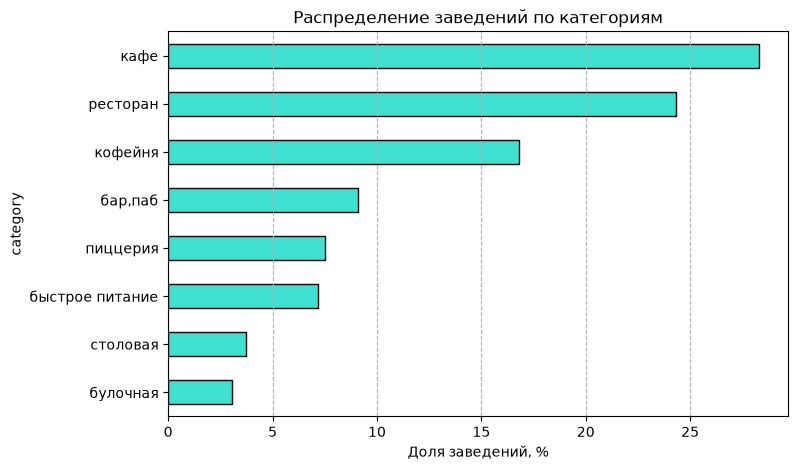

In [32]:
# Применим функцию для построения горизонтальной столбчатой диаграммы
plot_barh((df['category'].value_counts(normalize=True) * 100).round(2), 
          title='Распределение заведений по категориям', 
          xlabel='Доля заведений, %')

В данных представлено 8 категорий заведений общественного питания. Наибольшая доля - у кафе (28.28%) и ресторанов (24.30%). Вместе они составляют более половины всех заведений (52.58%). На третьем месте - кофейни (16.82%). Менее популярные категории: бар, паб (9.09%), пиццерия (7.53%), быстрое питание (7.18%). Наименьшие доли - у столовых (3.75%) и булочных (3.05%).

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

1. Рассмотрим распределение заведений по административным районам Москвы:

In [33]:
# Применим функцию для построения таблицы с количеством и долей (%) по значениям столбца
value_counts_summary(df, 'district')

,Количество,"Доля, %"
district,,
Центральный административный округ,2242,26.68
Северный административный округ,898,10.69
Южный административный округ,892,10.62
Северо-Восточный административный округ,890,10.59
Западный административный округ,850,10.12
Восточный административный округ,798,9.50
Юго-Восточный административный округ,714,8.50
Юго-Западный административный округ,709,8.44
Северо-Западный административный округ,409,4.87


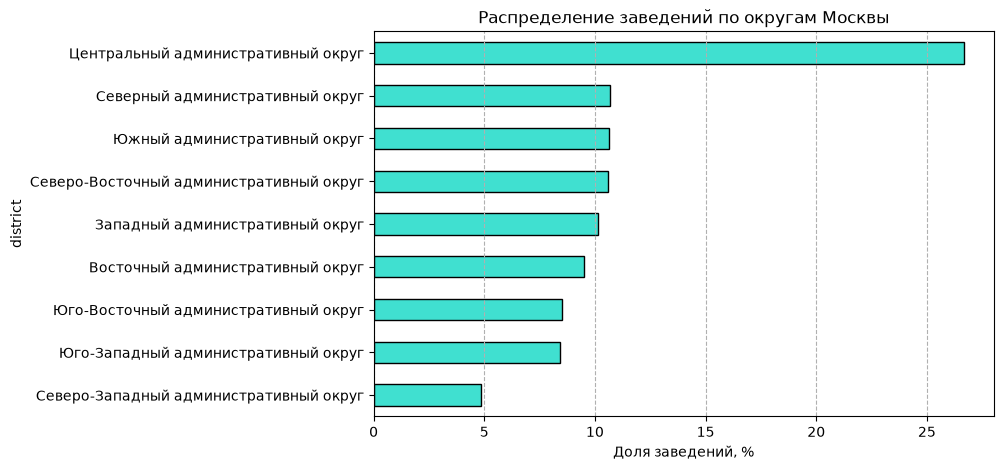

In [34]:
# Применим функцию для построения горизонтальной столбчатой диаграммы
plot_barh((df['district'].value_counts(normalize=True) * 100).round(2), 
          title='Распределение заведений по округам Москвы', 
          xlabel='Доля заведений, %')

Распределение заведений по административным округам Москвы неравномерно. Наибольшую долю рынка занимает Центральный административный округ (26.68% всех заведений). Остальные округа распределены относительно равномерно (от 8.44% до 10.69%). Наименьшая доля - у Северо-Западного округа (4.87%). Такое распределение отражает концентрацию бизнеса и спроса в центре города.

2. Рассмотрим распределение заведений каждой категории в Центральном административном округе Москвы:

In [35]:
# Фильтруем только Центральный административный округ
df_co = df[df['district'] == 'Центральный административный округ']
# Применим функцию для построения таблицы с количеством и долей (%) по значениям столбца
value_counts_summary(df_co, 'category')

,Количество,"Доля, %"
category,,
ресторан,670,29.88
кафе,464,20.70
кофейня,428,19.09
"бар,паб",364,16.24
пиццерия,113,5.04
быстрое питание,87,3.88
столовая,66,2.94
булочная,50,2.23


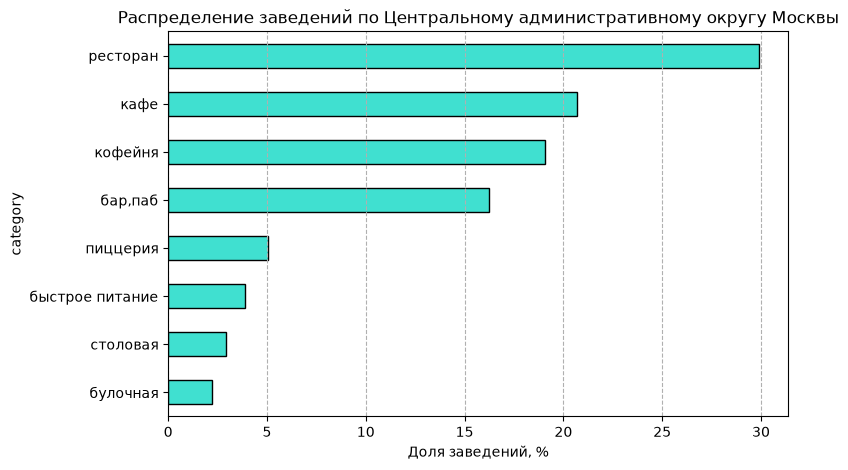

In [36]:
# Применим функцию для построения горизонтальной столбчатой диаграммы
plot_barh((df_co['category'].value_counts(normalize=True) * 100).round(2), 
          title='Распределение заведений по Центральному административному округу Москвы', 
          xlabel='Доля заведений, %')

В Центральном административном округе Москвы преобладают рестораны (29.88%), кафе (20.70%) и кофейни (19.09%). Вместе они составляют почти 70% всех заведений. Доля баров и пабов (16.24%) почти в 2 раза выше, чем в среднем по Москве (9.09%).  Наименьшие доли у столовых (2.94%) и булочных (2.23%). Это отражает специфику центра: здесь больше заведений для досуга и встреч, меньше - для повседневного питания.

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

1. Изучим соотношение сетевых и несетевых заведений в целом по всем данным:

In [37]:
# Применим функцию для построения таблицы с количеством и долей (%) по значениям столбца
chain_summary = value_counts_summary(df, 'chain')
chain_summary.index = ['Несетевые', 'Сетевые']
print(chain_summary)

           Количество  Доля, %
Несетевые        5199    61.88
Сетевые          3203    38.12


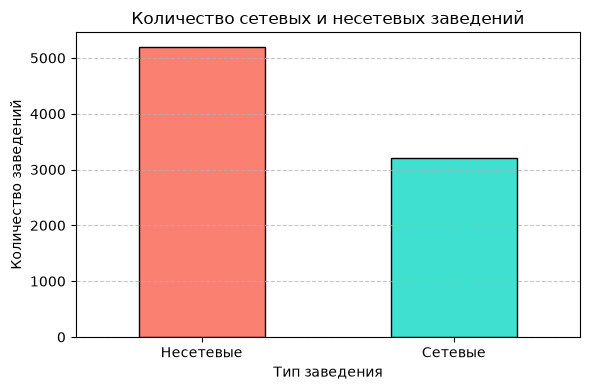

In [38]:
# Строим столбчатую диаграмму для визуализации количества сетевых и несетевых заведений
chain_summary['Количество'].plot(kind='bar',
                                  title='Количество сетевых и несетевых заведений',
                                  color=['salmon', 'turquoise'],
                                  edgecolor='black',
                                  figsize=(6, 4))

plt.ylabel('Количество заведений')
plt.xlabel('Тип заведения')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

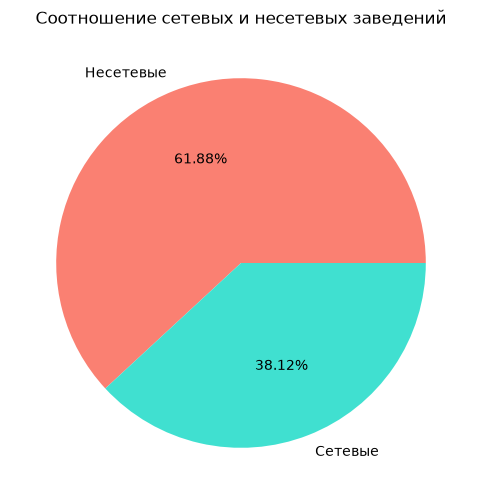

In [39]:
# Строим круговую диаграмму для визуализации соотношения сетевых и несетевых заведений
chain_summary['Доля, %'].plot(kind='pie',
                               autopct='%1.2f%%',
                               figsize=(6, 6),
                               colors=['salmon', 'turquoise'],
                               title='Соотношение сетевых и несетевых заведений')

plt.ylabel('')
plt.show()

В данных преобладают несетевые заведения - 5199 (61.88%). Сетевые составляют - 3203 (38.12%). 

2. Изучим соотношение сетевых и несетевых заведений в разрезе категорий:

In [40]:
#Группируем количество заведений по категориям в зависимости от того, является ли оно сетевым или нет
df_unstack = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
# Изменим названия колонок
df_unstack.columns = ['Несетевые', 'Сетевые']
# Рассчитаем долю сетевых заведений
df_unstack['Доля сетевых, %'] = round(df_unstack['Сетевые']/(df_unstack['Несетевые']+df_unstack['Сетевые'])*100, 2)
# Отсортируем по убыванию значения долей
df_unstack = df_unstack.sort_values('Доля сетевых, %', ascending=False)
df_unstack

,Несетевые,Сетевые,"Доля сетевых, %"
category,,,
булочная,99,157,61.33
пиццерия,303,330,52.13
кофейня,693,720,50.96
быстрое питание,371,232,38.47
ресторан,1313,729,35.70
кафе,1597,779,32.79
столовая,227,88,27.94
"бар,паб",596,168,21.99


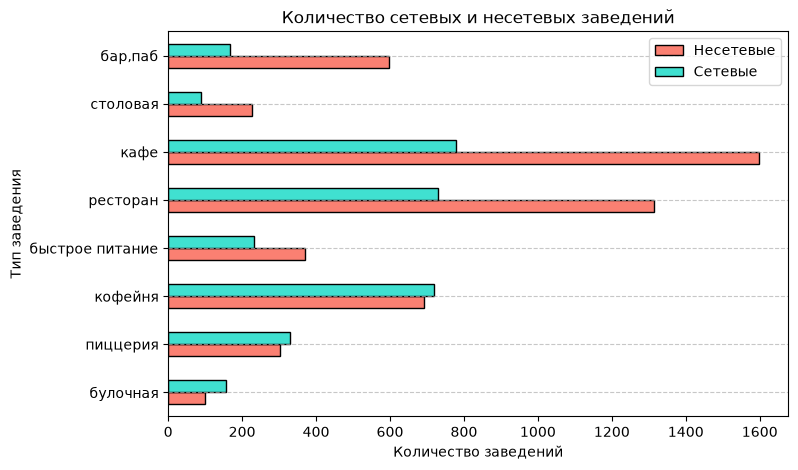

In [41]:
# Строим столбчатую диаграмму для визуализации количества сетевых и несетевых заведений
df_unstack[['Несетевые', 'Сетевые']].plot(kind='barh',
                                  title='Количество сетевых и несетевых заведений',
                                  color=['salmon', 'turquoise'],
                                  edgecolor='black',
                                  figsize=(8, 5))

plt.ylabel('Тип заведения')
plt.xlabel('Количество заведений')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

В большинстве категорий преобладают несетевые заведения. Лидеры по количеству несетевых заведений: кафе(1597) и рестораны(1313).

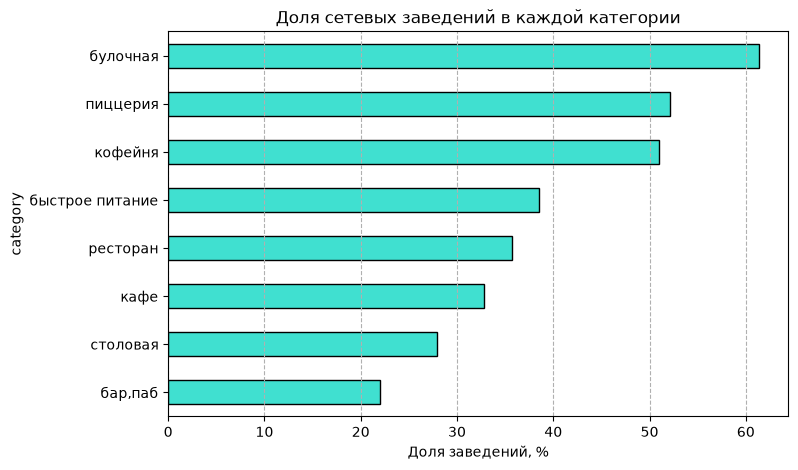

In [42]:
# Применим функцию построения горизонтальной столбчатой диаграммы 
#для визуализации процента сетевых заведений в каждой категории 

plot_barh(df_unstack['Доля сетевых, %'], 
          title='Доля сетевых заведений в каждой категории', 
          xlabel='Доля заведений, %')

Сетевые заведения доминируют в трёх категориях: булочные (61.33%), пиццерии (52.13%) и кофейни (50.96%).
В остальных категориях преобладают несетевые. Наименьшая доля сетевых заведений у баров и пабов (21.99%), столовых (27.94%) и кафе (32.79%). 

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.

1. Исследование количества посадочных мест в заведениях:

In [43]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count        4792.0
mean     108.361436
std       122.84113
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

В столбце seats обнаружены аномалии: минимальное значение - 0, максимальное - 1288. Это может быть связано с наличием крупных заведений (банкетные залы, рестораны), а также точек без посадочных мест (на вынос). Среднее (108.36) значительно превышает медиану (75), что говорит о правостороннем смещении распределения. Большинство заведений имеют до 140 мест.
Данные о количестве мест есть только у 4792 из 8402 заведений (57% пропусков), поэтому анализ охватывает только часть рынка.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с количество посадочных мест.

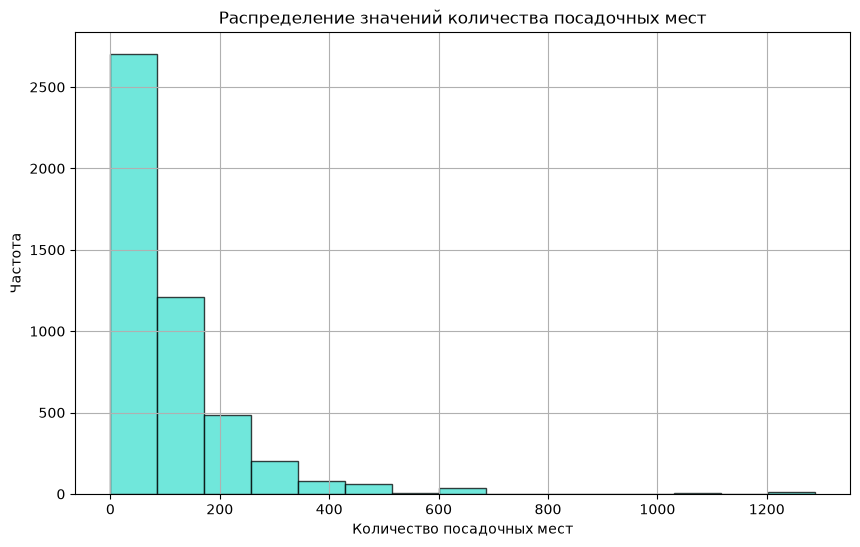

In [44]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(10, 6))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['seats'].plot(
                kind='hist', 
                bins=15, 
                alpha=0.75,
                color = 'turquoise',
                edgecolor='black',
                rot=0,
)

# Настраиваем оформление графика
plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Большинство заведений имеют до 100 мест, при этом 75% заведений — до 140 мест, после 200 частота резко падает. Единичные заведения с 600, 1000 и 1288 местами - это выбросы.

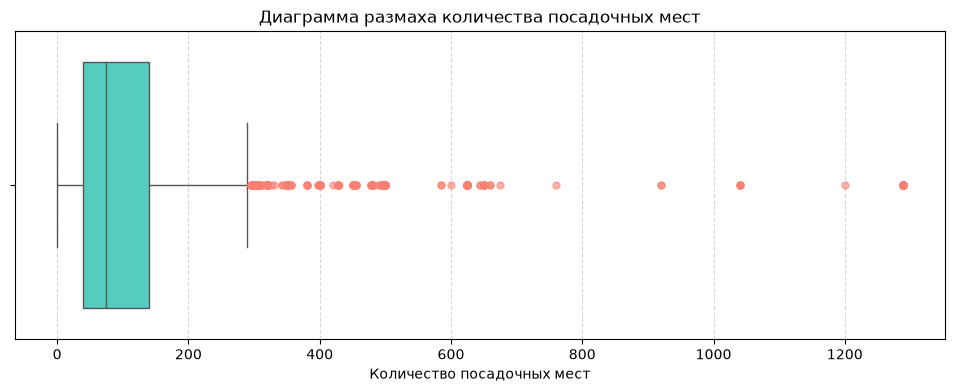

In [45]:
# Создаём контейнер графика и задаём размер — шире
plt.figure(figsize=(12, 4))

# Строим boxplot
sns.boxplot(x='seats', data=df,
            color='turquoise',          # turquoise — цвет ящика
            flierprops=dict(marker='o', 
                            markerfacecolor='salmon',  # salmon — выбросы
                            markeredgecolor='salmon',
                            markersize=5,
                            alpha=0.6))

# Подписи осей и заголовок
plt.title('Диаграмма размаха количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.ylabel('')
# Сетка
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Диаграмма размаха подтверждает правостороннее смещение: большинство заведений имеют до 140 мест, но есть множество выбросов - заведений с количеством мест от 300 до 1288. Это может быть связано с крупными ресторанами, банкетными залами и другими большими форматами.

2. Рассмотрим наиболее типичное значение (медиану) количества посадочных мест для каждой категории:

In [46]:
# Медиана по категориям
seats_by_category = df.groupby('category')['seats'].median().sort_values(ascending=False)
print(seats_by_category)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64


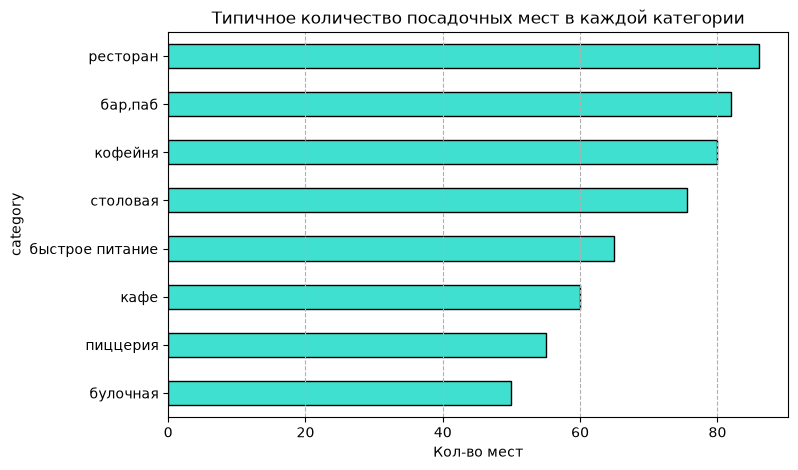

In [47]:
plot_barh(seats_by_category, 
          title='Типичное количество посадочных мест в каждой категории', 
          xlabel='Кол-во мест')

Наибольшее типичное значение количества посадочных мест у ресторанов - 86, баров и пабов - 82 и кофеен - 80. Наименьшее - у булочных - 50, пиццерий - 55 и кафе - 60. Разница значений между категориями не критичная, они находятся в диапазоне от 50 до 90 мест.

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

1. Исследование статистических показателей рейтинга по всем заведениям

In [48]:
# Изучаем статистические показатели столбца rating
print('Статистические показатели столбца rating:')
df['rating'].describe()

Статистические показатели столбца rating:


count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

Рейтинги заведений варьируются от 1.0 до 5.0, но большинство сконцентрированы в диапазоне от 4.1 до 4.4. Средний рейтинг - 4.23, медиана - 4.3. Распределение близко к нормальному, сильных выбросов нет. Минимальное значение (1.0) единичный случай, который можно изучить отдельно. Построим гистограмму для изучения распределения:

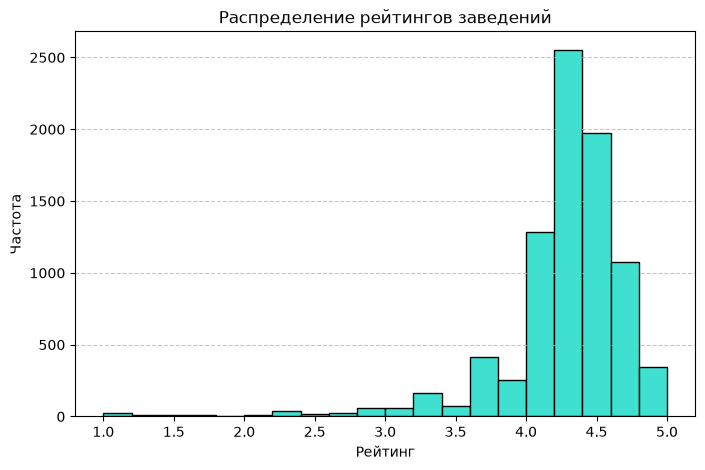

In [49]:
# Строим гистограмму распределения
plt.figure(figsize=(8, 5))
df['rating'].plot(kind='hist', bins=20, color='turquoise', edgecolor='black')
# Заголовок гистограммы, подписи осей и сетка
plt.title('Распределение рейтингов заведений')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Распределение рейтингов имеет левостороннюю скошенность: основная масса заведений сосредоточена в области высоких значений (4.0-5.0), а длинный хвост уходит в сторону низких рейтингов (1.0-3.0)

2. Исследование распределения средних рейтингов по категориям заведений

In [50]:
# Среднее значение рейтинга по категориям по категориям
rating_by_category = df.groupby('category')['rating'].mean().sort_values(ascending=False).round(2)
rating_by_category

category
бар,паб            4.39
пиццерия           4.30
ресторан           4.29
кофейня            4.28
булочная           4.27
столовая           4.21
кафе               4.12
быстрое питание    4.05
Name: rating, dtype: float64

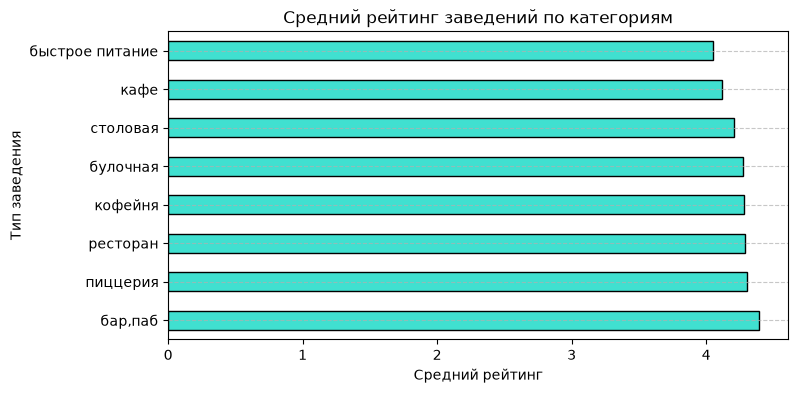

In [51]:
# Строим столбчатую диаграмму для визуализации количества сетевых и несетевых заведений
rating_by_category.plot(kind='barh',
                        title='Средний рейтинг заведений по категориям',
                        color='turquoise',
                        edgecolor='black',
                        figsize=(8, 4))

plt.ylabel('Тип заведения')
plt.xlabel('Средний рейтинг')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Средние рейтинги заведений по категориям различаются незначительно от 4.05 до 4.39. Самый высокий рейтинг у баров и пабов (4.39). Самый низкий у быстрого питания (4.05). Разница между лидером и аутсайдером - 0.34 балла, что говорит о стабильно высоком уровне заведений во всех сегментах. Это также объясняется тем, что большинство заведений имеют рейтинг выше 4.0, рынок в целом качественный.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

1. Изучение корреляции между данными:

In [52]:
# Вычисляем корреляционную матрицу с использованием phi_k
corr_matrix = df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7','rating']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['chain', 'seats', 'rating']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.220295
district,0.200761
category,0.189716
is_24_7,0.150365
chain,0.107833
seats,0.000000


Наибольшая корреляция рейтинга заведения наблюдается с ценовой категорией `price` - 0.22, административным округом `district` - 0.20 и категорией заведения `category` - 0.19. Далее связь снижается: с признаком круглосуточной работы `is_24_7` - 0.15, с сетевым статусом `chain` - 0.11. С количеством посадочных мест `seats` корреляция отсутствует.

Можно предположить, что цена связана с рейтингом — чем выше ценовая категория, тем выше ожидания клиентов и тем выше может быть рейтинг. Однако это гипотеза, которую нужно проверить отдельно.

Стоит отметить, что все коэффициенты корреляции слабые, так как ни один не превышает 0.25. Это значит, что рейтинг заведения не определяется одним фактором, а формируется под влиянием множества причин. 

2. Строим тепловую карту корреляции между рейтингом заведения и данными: его категорией, положением (административный район Москвы), статусом сетевого заведения, количеством мест, ценовой категорией и признаком, является ли заведение круглосуточным.

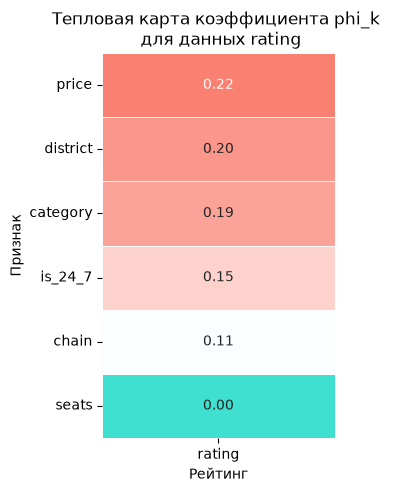

In [53]:
# Задаем размер будущей визуализации
plt.figure(figsize=(3, 5))

# Сохраняем матрицу корреляции признака rating с другими признаками клиента
data_heatmap = corr_matrix.loc[corr_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

# С помощью LinearSegmentedColormap cоздаём свою цветовую палитру для тепловой карты (бирюзовый - белый - лососевый)
my_cmap = LinearSegmentedColormap.from_list(
    'turquoise_white_salmon',
    ['#40E0D0', '#FFFFFF', '#FA8072']
)
# Строим тепловую карту 
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap=my_cmap,
            linewidths=0.5, 
            cbar=False 
           )
# Названия признаков горизонтально
plt.yticks(rotation=0)
# Добавляем заголовок и подписи осей
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')
plt.ylabel('Признак')

# Выводим график
plt.show()

3. Посмотрим, как распределены рейтинги по ценовым категориям.


In [54]:
# Считаем средний рейтинг по ценовым категориям
rating_by_price = df.groupby('price')['rating'].mean().round(2).sort_values(ascending=False)
rating_by_price

price
высокие          4.44
выше среднего    4.39
средние          4.30
низкие           4.17
Name: rating, dtype: float64

4. Для визуализации связи рейтинга с ценовой категорией был выбран линейный график, потому что ценовые категории имеют порядок от низкой к высокой. График покажет тренд и поможет ответить на вопрос: растёт ли рейтинг с ростом цены.



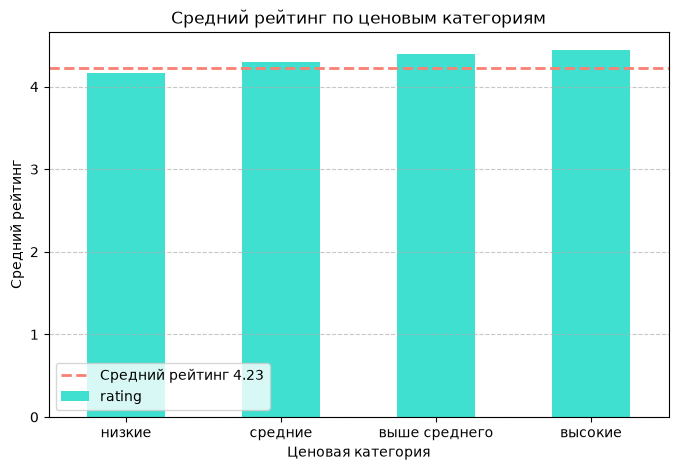

In [55]:
# Упорядочим категории price от низкой к высокой
price_order = ['низкие', 'средние', 'выше среднего', 'высокие']
rating_by_price = rating_by_price.reindex(price_order)
# Строим линейный график
plt.figure(figsize=(8, 5))
rating_by_price.plot(kind='bar', color='turquoise')
#Добавляем на график заголовок, подписи осей и сетку
plt.title('Средний рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Рассчитаем средний рейтинг по всем заведениям
mean_rating = df['rating'].mean()
# Добавим на график горизонтальную линию со значением среднего рейтинга всех заведений
plt.axhline(mean_rating, color='salmon', linestyle='--', linewidth=2, 
            label=f'Средний рейтинг {mean_rating:.2f}')
plt.legend()
plt.show()

Средний рейтинг растёт с увеличением ценовой категории: от 4.17 у «низких» до 4.44 у «высоких». Это подтверждает гипотезу о положительной связи между ценой и рейтингом. Разница - 0.27 балла, что говорит о слабой, но заметной связи.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

1. Сгруппируем данные по названиям заведений, рассчитаем количество точек в сети, на основе полученного значения составим топ-15 популярных сетей в Москве. В полученный датафрейм также добавим столбец с категорией заведения.

In [56]:
# Сгруппируем данные по названиям заведений, выведем топ-15 популярных сетей в Mоскве
top15 = (df[df['chain'] == 1] # Проверка, является ли заведение сетевым
         .groupby('name')['rating']
         .agg(['count', 'mean'])
         .sort_values(by='count', ascending=False)
         .round(2)
         .head(15))

# Добавляем категорию — первую в группе
category_map = df.groupby('name')['category'].first()
top15['category'] = top15.index.map(category_map)
# Переставляем столбцы: category, count, mean
top15 = top15[['category', 'count', 'mean']]

top15

,category,count,mean
name,,,
шоколадница,кофейня,120,4.18
домино'с пицца,пиццерия,76,4.17
додо пицца,пиццерия,74,4.29
one price coffee,кофейня,71,4.06
яндекс лавка,ресторан,69,3.87
cofix,кофейня,65,4.08
prime,ресторан,50,4.12
хинкальная,быстрое питание,44,4.32
кофепорт,кофейня,42,4.15


Лидерами по количеству заведений сети являются кофейня `"Шоколадница"` - 120 точек и пиццерии `"Домино'с пицца"` - 76 точек, `"Додо пицца"` - 74. Топ-15 замыкает кафе `"Му-Му"` - 27 точек.

2. Изучим распределение количества сетей по категориям в топ-15:

In [57]:
# Считаем количество сетей по категориям в топ-15
category_counts = top15['category'].value_counts()
category_counts

category
кофейня            5
ресторан           3
кафе               3
пиццерия           2
быстрое питание    1
булочная           1
Name: count, dtype: int64

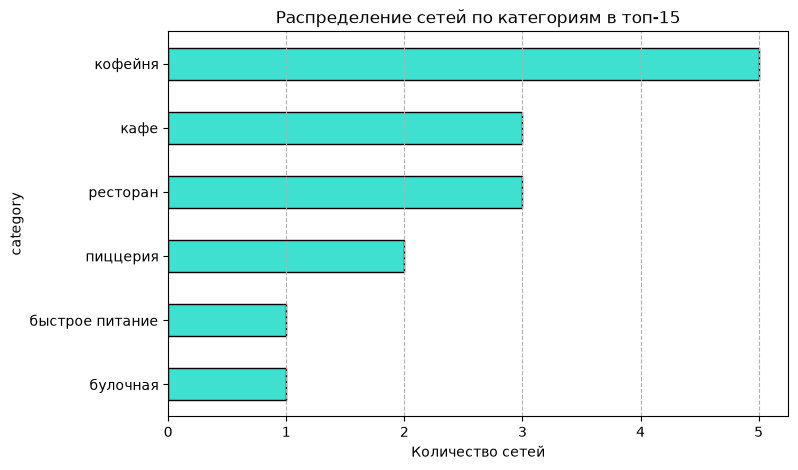

In [58]:
plot_barh(category_counts,
          title='Распределение сетей по категориям в топ-15',
          xlabel='Количество сетей')

В топ-15 популярных сетей Москвы преобладают кофейни - 5 позиций. Далее следуют кафе и рестораны по 3 позиции. Пиццерии представлены двумя сетями, а булочные и быстрое питание по одной.

3. Для визуализации количества заведений и среднего рейтинга были выбраны горизонтальные столбчатые диаграммы, расположенные рядом. Слева - количество заведений, справа - средний рейтинг. Такой формат позволяет сравнить оба показателя для каждой сети и увидеть, есть ли между ними связь.

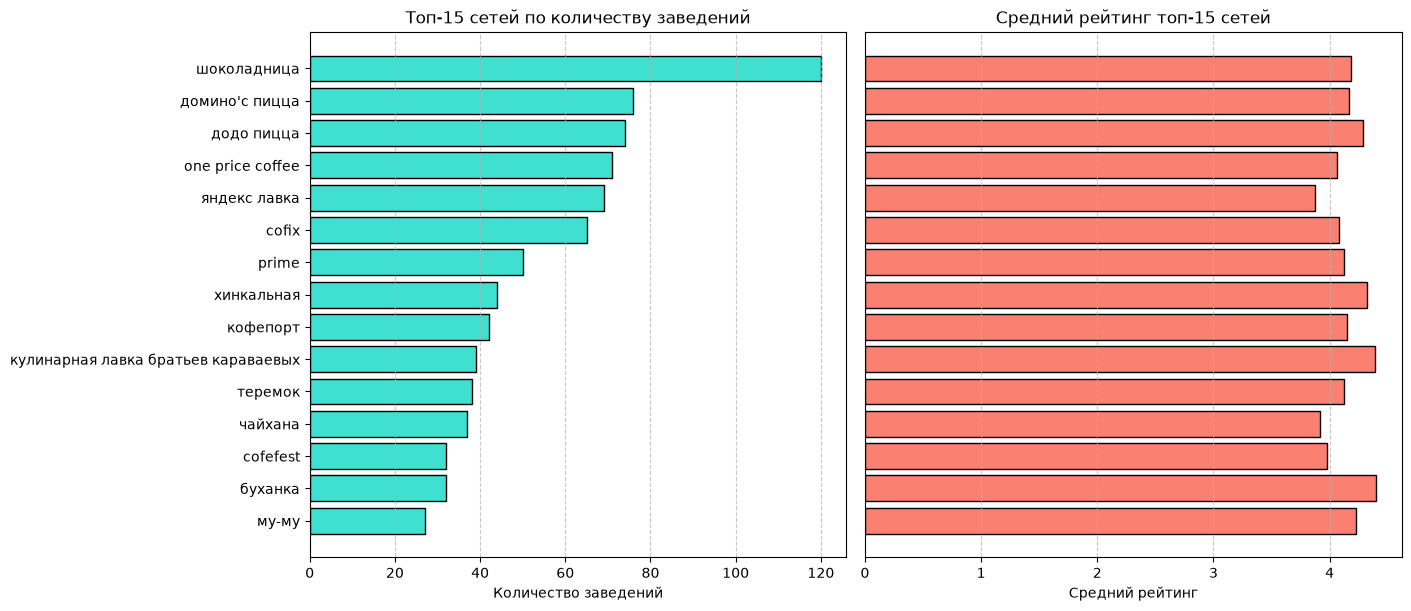

In [59]:
# Создаём фигуру с двумя подграфиками рядом (1 строка, 2 столбца)
# constrained_layout=True автоматически распределяет отступы
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Сортируем данные по возрастанию, чтобы самая большая сеть была сверху
top15_sorted = top15.sort_values('count', ascending=True)

# Слева количество
axes[0].barh(top15_sorted.index, top15_sorted['count'],
             color='turquoise', edgecolor='black')
axes[0].set_title('Топ-15 сетей по количеству заведений', fontsize=12)
axes[0].set_xlabel('Количество заведений')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Справа средний рейтинг
axes[1].barh(top15_sorted.index, top15_sorted['mean'],
             color='salmon', edgecolor='black')
axes[1].set_title('Средний рейтинг топ-15 сетей', fontsize=12)
axes[1].set_xlabel('Средний рейтинг')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', left=False, labelleft=False)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Лидер по количеству заведений «Шоколадница» - 120 точек. Наибольший средний рейтинг у «Буханки» (4.40) и «Кулинарной лавки братьев Караваевых» (4.39). Наименьший у «Яндекс Лавки» (3.87).
Связи между количеством заведений и средним рейтингом не наблюдается: у крупных сетей рейтинг средний, а у небольших - высокий. Популярность сети не гарантирует высокого рейтинга.

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.

1. Изучим статистические показатели столбца middle_avg_bill, чтобы понять, есть ли выбросы в данных по среднему чеку.

In [60]:
# Изучаем статистические показатели столбца middle_avg_bill
print('Статистические показатели столбца middle_avg_bill:')
df['middle_avg_bill'].describe()

Статистические показатели столбца middle_avg_bill:


count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

В столбце `middle_avg_bill` обнаружены аномалии: минимальное значение - 0, максимальное - 35 000. Среднее (958) значительно превышает медиану (750), что говорит о правостороннем смещении распределения. Это может быть связано с наличием крупных заведений (банкетные залы, элитные рестораны) или ошибками в данных. Большинство заведений имеют средний чек до 1250 ₽.

Для поиска выбросов в среднем чеке использован ящик с усами, он наглядно показывает аномальные значения.

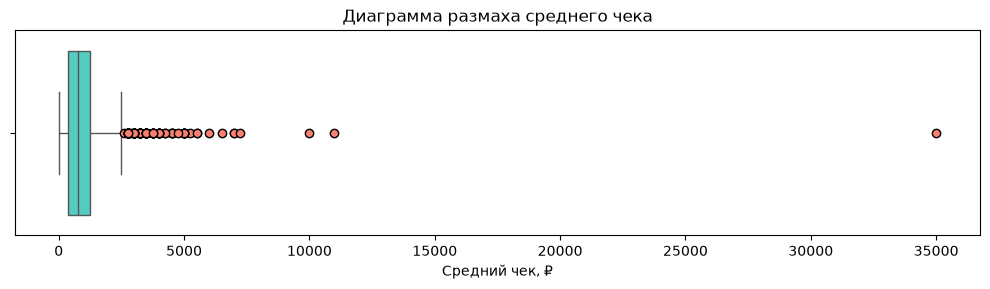

In [61]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df['middle_avg_bill'],
    color='turquoise',
    flierprops=dict(marker='o', markerfacecolor='salmon', 
                    markersize=6, markeredgecolor='black')
)

plt.title('Диаграмма размаха среднего чека')
plt.xlabel('Средний чек, ₽')
plt.tight_layout()
plt.show()

На диаграмме размаха видны многочисленные выбросы - заведения со средним чеком от 3000 до 35 000 ₽. Это может быть связано с наличием элитных ресторанов, банкетных залов и заведений высокого ценового сегмента. Из-за этих выбросов среднее значение (958 ₽) значительно превышает медиану (750 ₽), поэтому для анализа типичного чека надёжнее использовать медиану.

2. Сгруппируем заведения по районам с расчетом медианы и среднего значения среднего чека заведений. 

In [62]:
# Расчет медианы и среднего по округам
district_stats = df.groupby('district')['middle_avg_bill'].agg(['median', 'mean']).round(2)
district_stats = district_stats.sort_values('mean', ascending=False)
district_stats

,median,mean
district,,
Центральный административный округ,1000.0,1191.06
Западный административный округ,1000.0,1053.23
Северный административный округ,650.0,927.96
Южный административный округ,500.0,834.40
Северо-Западный административный округ,700.0,822.22
Восточный административный округ,575.0,820.63
Юго-Западный административный округ,600.0,792.56
Северо-Восточный административный округ,500.0,716.61
Юго-Восточный административный округ,450.0,654.10


Центральный административный округ лидирует по величине среднего чека - 1191.06, а Юго-Восточный административный округ замыкает список - 654.10. Медианное значение в ЦАО и ЗАО составляет 1000, а Юго-Восточный округ также имеет самое низкое значение - 450. Среднее значение везде превышает медиану, что говорит о правостороннем смещении распределения: в каждом округе есть заведения с высоким чеком, которые вытягивают среднее вверх.

In [63]:
# Отфильтруем центральный округ
df_co = df[df['district'] == 'Центральный административный округ']

# Отфильтруем остальные округа
df_other = df[df['district'] != 'Центральный административный округ']

# Медиана
print(f"Медиана в ЦАО: {df_co['middle_avg_bill'].median():.2f}")
print(f"Медиана в остальных: {df_other['middle_avg_bill'].median():.2f}")
print(f"Разница медиан: {df_co['middle_avg_bill'].median() - df_other['middle_avg_bill'].median():.2f}")

# Среднее
print(f"Среднее в ЦАО: {df_co['middle_avg_bill'].mean():.2f}")
print(f"Среднее в остальных: {df_other['middle_avg_bill'].mean():.2f}")
print(f"Разница средних: {df_co['middle_avg_bill'].mean() - df_other['middle_avg_bill'].mean():.2f}")

Медиана в ЦАО: 1000.00
Медиана в остальных: 600.00
Разница медиан: 400.00
Среднее в ЦАО: 1191.06
Среднее в остальных: 839.82
Разница средних: 351.23


Средний чек заведений различается по административным округам Москвы. Наибольший средний чек в Центральном административном округе - 1191.06, что связано с концентрацией ресторанов и заведений высокого ценового сегмента. В остальных округах средний чек ниже на 351.23. Медиана - 1000  против 600 (разница 400). В центре чек выше и по среднему, и по медиане.



In [64]:
plot_barh(avg_bill_district,
          title='Медиана среднего чека по административным округам Москвы',
          xlabel='Средний чек, ₽',
          color='turquoise')

NameError: name 'avg_bill_district' is not defined

Таким образом, чем ближе к центру, тем выше цены в заведениях. Это подтверждает гипотезу о влиянии удалённости от центра на ценовую политику заведений.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

- В данных представлено 8402 заведения 8 категорий. Наибольшую часть рынка занимают кафе (28.28%) и рестораны (24.30%). Вместе они составляют более половины всех заведений (52.58%).

- Несетевых заведений больше (61.88%), чем сетевых (38.12%). Сетевые преобладают в булочных (61.33%), пиццериях (52.13%) и кофейнях (50.96%).

- Количество посадочных мест сильно варьируется: от 0 до 1288. Медиана - 75 мест. Типичное количество мест - 50–90 в зависимости от категории.

- Средний рейтинг заведений  4.23. Разброс по категориям незначительный: от 4.05 (быстрое питание) до 4.39 (бар, паб).

- Наибольшая корреляция рейтинга выявлена с ценовой категорией (0.22), связь слабая, но положительная: чем выше цена, тем выше рейтинг.

- Средний чек в Центральном административном округе 1191, что на 351 выше, чем в остальных округах. Можно сделать вывод, что чем ближе заведение находится к центру, тем выше средний чек.


---


<a id="conclusion"></a>
## 4. Итоговый вывод и рекомендации

 **1. Общий обзор проделанной работы**
 
Проведён исследовательский анализ 8402 заведений общественного питания Москвы на основе двух датасетов. Данные объединены в единый датафрейм, проведена предобработка: приведены типы, обработаны пропуски, удалены неявные дубликаты, добавлен признак is_24_7. Были изучены 8 направлений: категории, округа, сетевой формат, посадочные места, рейтинг, корреляция, топ-15 сетей, средний чек по округам.

**2. Главные выводы**

- *Категории.* Преобладают кафе (28.28%) и рестораны (24.30%), вместе они занимают более половины рынка (52.58%). Меньше всего столовых (3.75%) и булочных (3.05%). Это может говорить о том, что кафе и рестораны являются наиболее востребованными форматами в городе, но для точного вывода нужны дополнительные данные.

- *География.* Лидером является Центральный административный округ (26.68%). В ЦАО преобладают рестораны (29.88%), а доля баров и пабов (16.24%) почти в 2 раза выше, чем в среднем по Москве (9.09%).  Такое распределение отражает специфику центра: здесь больше заведений для досуга и встреч и меньше для повседневного питания.

- *Сетевой формат.* Несетевых заведений больше 61.88% против 38.12% сетевых. Но в то же время сетевые преобладают в булочных (61.33%), пиццериях (52.13%) и кофейнях (50.96%). Возможно, это связано с тем, что такие форматы легче масштабируются, но для точного вывода нужны дополнительные данные. Меньше всего сетей - среди баров и пабов (21.99%), они являются более локальными.

- *Посадочные места.* Медианное значение - 75 мест. Типичное количество от 50 до 90 в зависимости от категории. Минимальные значения 0 - точки «на вынос», максимальные 1288 - крупные банкетные залы. Такое распределение подтверждает: большинство заведений небольшие, а крупные форматы редкость.

- *Рейтинг.* Средний рейтинг - 4.23, медиана - 4.3. Разброс по категориям незначительный: от 4.05 (быстрое питание) до 4.39 (бар, паб). Это говорит о стабильно высоком уровне заведений во всех сегментах. Рынок в целом качественный.

- *Корреляция.* Наибольшая связь рейтинга наблюдается с ценовой категорией (0.22). Связь слабая, но положительная: чем выше цена, тем выше рейтинг. Однако коэффициент 0.22 означает, что рейтинг формируется под влиянием множества факторов, а не только цены. Остальные признаки (округ, категория, круглосуточность, сетевой статус) показали ещё более слабую связь, а количество мест не связано с рейтингом вовсе.

- *Топ-15 сетей.* Преобладают кофейни (5), кафе (3) рестораны (3). Лидер по количеству точек -  «Шоколадница» (120), но наибольший рейтинг - у булочной «Буханка» (4.40). Связи между количеством точек и рейтингом нет: у крупных сетей рейтинг средний, а у небольших - высокий. Популярность сети не гарантирует высокого рейтинга.

- *Средний чек.* Средний чек в ЦАО выше, чем в остальных округах, и по среднему (1191 ₽ против 840 ₽, разница 351 ₽), и по медиане (1000 ₽ против 600 ₽, разница 400 ₽). Чем ближе заведение к центру, тем выше чек. Это подтверждает гипотезу о влиянии удалённости от центра на ценовую политику.



**3. Рекомендации заказчику**

- *Локация.* Стоит присмотреться к Западному административному округу. Он второй по среднему чеку (1053 ₽) после ЦАО, но конкуренция там заметно ниже 10.12% против 26.68% в центре. Это даёт шанс занять нишу с высоким средним чеком без прямой борьбы с центром. При этом в ЗАО уже есть заведения с высоким чеком (медиана 1000 ₽), что подтверждает спрос на дорогой сегмент. Если открыть там заведение с уникальной концепцией, можно привлечь платёжеспособную аудиторию, не конкурируя с центром напрямую.

- *Формат.* Если нужна масштабируемость сети, выбирать кофейни, пиццерии или булочные (там сетевой формат уже преобладает). Если хочется больше уникальности - бары, столовые и авторские кафе.

- *Ценообразование.* Не стоит занижать цену, так как данные показывают слабую, но устойчивую связь между высокой ценой и высоким рейтингом.

- *Вместимость.* Стоит ориентироваться на 75–90 - это медианное значение количества посадочных мест. Крупные форматы (300+ мест) являются исключением.

- *Режим работы.* Круглосуточный формат - редкость (8.7%), можно рассмотреть. Стоит рассматривать формат работы заведения в зависимости от выбранной категории и того, что находится в районе поблизости.

- Важно отметить, что большая часть заведений (более 50%) не имеют полных данных, поэтому требуется более тщательный анализ рынка в конкретной области и категории.